# Параметрический резонанс при экспоненциальном росте частоты

## Условие задачи

Частота колебаний частицы растёт со временем по закону $\omega(t) = \omega_0 e^{\lambda t}$, так что уравнение движения имеет вид
$$ \ddot{x} + \omega_0^2 e^{2\lambda t} x = 0. $$
Требуется найти транспортную матрицу, вычислить адиабатический инвариант и показать его сохранение, а также провести качественный анализ фазовых траекторий.

Решение выражается через функции Бесселя нулевого и первого порядков:
$$ x(t) = C_1 J_0\left(\frac{\omega(t)}{\lambda}\right) + C_2 Y_0\left(\frac{\omega(t)}{\lambda}\right), \qquad
\dot{x}(t) = -\omega(t) \left[ C_1 J_1\left(\frac{\omega(t)}{\lambda}\right) + C_2 Y_1\left(\frac{\omega(t)}{\lambda}\right) \right]. $$
Далее приводится вывод этого решения, строится транспортная матрица и проверяется сохранение адиабатического инварианта.

## Аналитическое решение

Уравнение приводится к уравнению Бесселя заменой переменной $\tau = \dfrac{\omega_0}{\lambda} e^{\lambda t}$, для которой $\dfrac{d\tau}{dt} = \lambda \tau$.
Производные по времени выражаются через производные по $\tau$:
$$ \frac{dx}{dt} = \frac{dx}{d\tau} \frac{d\tau}{dt} = \lambda \tau \frac{dx}{d\tau}, \qquad
\frac{d^2x}{dt^2} = \lambda \tau \frac{d}{d\tau} \left( \lambda \tau \frac{dx}{d\tau} \right) = \lambda^2 \tau \left( \frac{dx}{d\tau} + \tau \frac{d^2x}{d\tau^2} \right). $$
После подстановки в исходное уравнение с учётом равенства $\omega_0^2 e^{2\lambda t} = \lambda^2 \tau^2$ получается
$$ \lambda^2 \tau \frac{dx}{d\tau} + \lambda^2 \tau^2 \frac{d^2x}{d\tau^2} + \lambda^2 \tau^2 x = 0, $$
а после деления на $\lambda^2$
$$ \tau^2 \frac{d^2x}{d\tau^2} + \tau \frac{dx}{d\tau} + \tau^2 x = 0. $$
Это уравнение Бесселя нулевого порядка, общее решение которого
$$ x(\tau) = C_1 J_0(\tau) + C_2 Y_0(\tau), $$
где $J_0$ и $Y_0$ — функции Бесселя первого и второго рода.
Возвращаясь к переменной $t$, получаем
$$ x(t) = C_1 J_0\left(\frac{\omega(t)}{\lambda}\right) + C_2 Y_0\left(\frac{\omega(t)}{\lambda}\right). $$
Скорость частицы находится дифференцированием с учётом тождества $Z_0'(\tau) = -Z_1(\tau)$, справедливого для обеих функций Бесселя:
$$ \dot{x}(t) = \lambda \tau \frac{dx}{d\tau} = \omega(t) \left[ C_1 J_0'(\tau) + C_2 Y_0'(\tau) \right] = -\omega(t) \left[ C_1 J_1\left(\frac{\omega(t)}{\lambda}\right) + C_2 Y_1\left(\frac{\omega(t)}{\lambda}\right) \right]. $$

Аналитическое решение реализовано численно: по начальным условиям находятся константы $C_1$ и $C_2$, после чего вычисляются координата, скорость и адиабатический инвариант.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0, y0, j1, y1

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
def solve_parametric_oscillator(t, x0, v0, omega0, lam):
    """
    Вычисляет аналитическое решение для параметрического осциллятора.
    """
    # Текущая частота
    omega_t = omega0 * np.exp(lam * t)
    
    # Аргумент функций Бесселя
    tau = omega_t / lam
    tau0 = omega0 / lam # t=0
    
    # Определитель системы для начальных условий (Вронскиан модифицированный)
    # Delta = (2 * lam) / np.pi # Аналитическое значение
    # Вычислим численно для проверки согласованности
    Delta = -omega0 * (j0(tau0)*y1(tau0) - y0(tau0)*j1(tau0))
    
    # Константы C1 и C2 из начальных условий
    # x0 = C1*J0(tau0) + C2*Y0(tau0)
    # v0 = -omega0 * (C1*J1(tau0) + C2*Y1(tau0))
    
    C1 = (1/Delta) * (x0 * (-omega0 * y1(tau0)) - v0 * y0(tau0))
    C2 = (1/Delta) * (x0 * (omega0 * j1(tau0)) + v0 * j0(tau0))
    
    # Решение
    x = C1 * j0(tau) + C2 * y0(tau)
    v = -omega_t * (C1 * j1(tau) + C2 * y1(tau))
    
    return x, v, omega_t

# Параметры задачи
omega0 = 2 * np.pi * 1.0  # Начальная частота (1 Гц)
lam = 0.1 * omega0        # Скорость роста частоты (медленная по сравнению с частотой)
t_max = 5.0               # Время моделирования
dt = 0.001
t = np.arange(0, t_max, dt)

# Начальные условия
x0 = 1.0
v0 = 0.0

# Вычисление
x, v, omega_t = solve_parametric_oscillator(t, x0, v0, omega0, lam)

# Адиабатический инвариант I = E / omega
# E = v^2/2 + omega^2 * x^2 / 2
# I = (v^2 + omega^2 * x^2) / (2 * omega)
I = (v**2 + omega_t**2 * x**2) / (2 * omega_t)

## Транспортная матрица

Транспортная матрица $M(t, t_0)$ связывает координату и скорость в момент $t$ с начальными условиями $(x_0, \dot{x}_0)$ в момент $t_0$.
Обозначим $\tau_0 = \omega(t_0)/\lambda$ и запишем систему уравнений для констант:
$$ x_0 = C_1 J_0(\tau_0) + C_2 Y_0(\tau_0), \qquad \dot{x}_0 = -\omega(t_0) \left[ C_1 J_1(\tau_0) + C_2 Y_1(\tau_0) \right]. $$
Определитель системы
$$ \Delta = -\omega(t_0) \left[ J_0(\tau_0) Y_1(\tau_0) - Y_0(\tau_0) J_1(\tau_0) \right] $$
вычисляется по тождеству для функций Бесселя $J_0(z) Y_1(z) - Y_0(z) J_1(z) = -\dfrac{2}{\pi z}$:
$$ \Delta = \omega(t_0) \frac{2}{\pi \tau_0} = \frac{2\lambda}{\pi}. $$
По формулам Крамера
$$ C_1 = \frac{\pi}{2\lambda} \left[ -x_0 \omega(t_0) Y_1(\tau_0) - \dot{x}_0 Y_0(\tau_0) \right], \qquad
C_2 = \frac{\pi}{2\lambda} \left[ \dot{x}_0 J_0(\tau_0) + x_0 \omega(t_0) J_1(\tau_0) \right]. $$
После подстановки $C_1$ и $C_2$ в выражения для $x(t)$ и $\dot{x}(t)$ и группировки слагаемых при $x_0$ и $\dot{x}_0$ получаются элементы матрицы $M$:
$$ m_{11} = \frac{\partial x(t)}{\partial x_0} = \frac{\pi \omega(t_0)}{2\lambda} \left[ J_1(\tau_0) Y_0(\tau) - Y_1(\tau_0) J_0(\tau) \right], $$
$$ m_{12} = \frac{\partial x(t)}{\partial \dot{x}_0} = \frac{\pi}{2\lambda} \left[ J_0(\tau_0) Y_0(\tau) - Y_0(\tau_0) J_0(\tau) \right], $$
$$ m_{21} = \frac{\partial \dot{x}(t)}{\partial x_0} = \frac{\pi \omega(t) \omega(t_0)}{2\lambda} \left[ Y_1(\tau_0) J_1(\tau) - J_1(\tau_0) Y_1(\tau) \right], $$
$$ m_{22} = \frac{\partial \dot{x}(t)}{\partial \dot{x}_0} = \frac{\pi \omega(t)}{2\lambda} \left[ Y_0(\tau_0) J_1(\tau) - J_0(\tau_0) Y_1(\tau) \right]. $$
При $t = t_0$ диагональные элементы обращаются в единицу, а внедиагональные в нуль, как и должно быть для тождественного преобразования.
Система гамильтонова, и фазовый объём сохраняется по теореме Лиувилля, так что определитель матрицы $\det M = m_{11} m_{22} - m_{12} m_{21}$ равен единице.
Это равенство служит проверкой формул.
Оно проверяется численно вместе с тем, что матрица переводит начальные условия в аналитическое решение.

In [3]:
def get_transport_matrix(t_val, t0_val, omega0, lam):
    """
    Транспортная матрица M(t, t0) для осциллятора с частотой omega0 * exp(lam * t).
    Элементы получены подстановкой C1, C2 в x(t) и v(t); 1/Delta = pi / (2 lam).
    """
    omega_t = omega0 * np.exp(lam * t_val)
    omega_t0 = omega0 * np.exp(lam * t0_val)
    tau = omega_t / lam
    tau0 = omega_t0 / lam
    factor = np.pi / (2 * lam)

    m11 = factor * omega_t0 * (j1(tau0) * y0(tau) - y1(tau0) * j0(tau))
    m12 = factor * (j0(tau0) * y0(tau) - y0(tau0) * j0(tau))
    m21 = factor * omega_t * omega_t0 * (y1(tau0) * j1(tau) - j1(tau0) * y1(tau))
    m22 = factor * omega_t * (y0(tau0) * j1(tau) - j0(tau0) * y1(tau))
    return np.array([[m11, m12], [m21, m22]])

# Матрица для t = 2.0
t_target = 2.0
M = get_transport_matrix(t_target, 0, omega0, lam)
print(f"Транспортная матрица M(t={t_target}, t0=0):")
print(M)

# Проверка 1: система гамильтонова, фазовый объём сохраняется -> det M = 1
print(f"Определитель матрицы: {np.linalg.det(M):.6f} (должен быть 1.0)")

# Проверка 2: матрица переводит начальные условия в аналитическое решение
x_t, v_t, _ = solve_parametric_oscillator(np.array([t_target]), x0, v0, omega0, lam)
x_M, v_M = M @ np.array([x0, v0])
print(f"x(t): по матрице {x_M:.6f}, аналитически {x_t[0]:.6f}")
print(f"v(t): по матрице {v_M:.6f}, аналитически {v_t[0]:.6f}")

Транспортная матрица M(t=2.0, t0=0):
[[5.34070053e-01 1.01782300e-03]
 [2.77955777e-01 1.87294327e+00]]
Определитель матрицы: 1.000000 (должен быть 1.0)
x(t): по матрице 0.534070, аналитически 0.534070
v(t): по матрице 0.277956, аналитически 0.277956


## Адиабатический инвариант и фазовые траектории

Для гармонического осциллятора с медленно меняющейся частотой адиабатическим инвариантом является отношение энергии к частоте:
$$ I = \frac{E}{\omega} = \frac{\dot{x}^2 + \omega^2 x^2}{2\omega}. $$
В рассматриваемой задаче частота растёт экспоненциально, и при медленном изменении ($\lambda \ll \omega$) инвариант сохраняется с точностью до малых поправок, а энергия осциллятора растёт пропорционально частоте.
Энергия осциллятора единичной массы выражается через амплитуду как $E = \frac{1}{2} \omega^2 A^2$, поэтому
$$ I = \frac{1}{2} \omega A^2. $$
При $I = \text{const}$ квадрат амплитуды убывает обратно пропорционально частоте, $A^2 \sim 1/\omega \sim e^{-\lambda t}$, и амплитуда затухает как $A \sim e^{-\lambda t/2}$.
Тот же результат следует из асимптотики функций Бесселя при большом аргументе, $J_0(\tau) \approx \sqrt{2/\pi\tau} \cos(\tau - \pi/4)$, поскольку $\tau \propto \omega$.

В фазовом пространстве $(x, \dot{x})$ при постоянной частоте траектории представляют собой эллипсы.
При растущей частоте амплитуда координаты уменьшается как $e^{-\lambda t/2}$, а амплитуда скорости $\omega A$ растёт как $e^{\lambda t/2}$.
Фазовая траектория представляет собой спираль, которая сжимается по оси $x$ и растягивается по оси $\dot{x}$.
Площадь, ограниченная витком спирали, равна $2\pi I$ и при адиабатическом изменении частоты сохраняется.

На графиках показаны колебания координаты с теоретической огибающей $x_0 e^{-\lambda t/2}$, фазовая траектория и зависимость инварианта от времени.

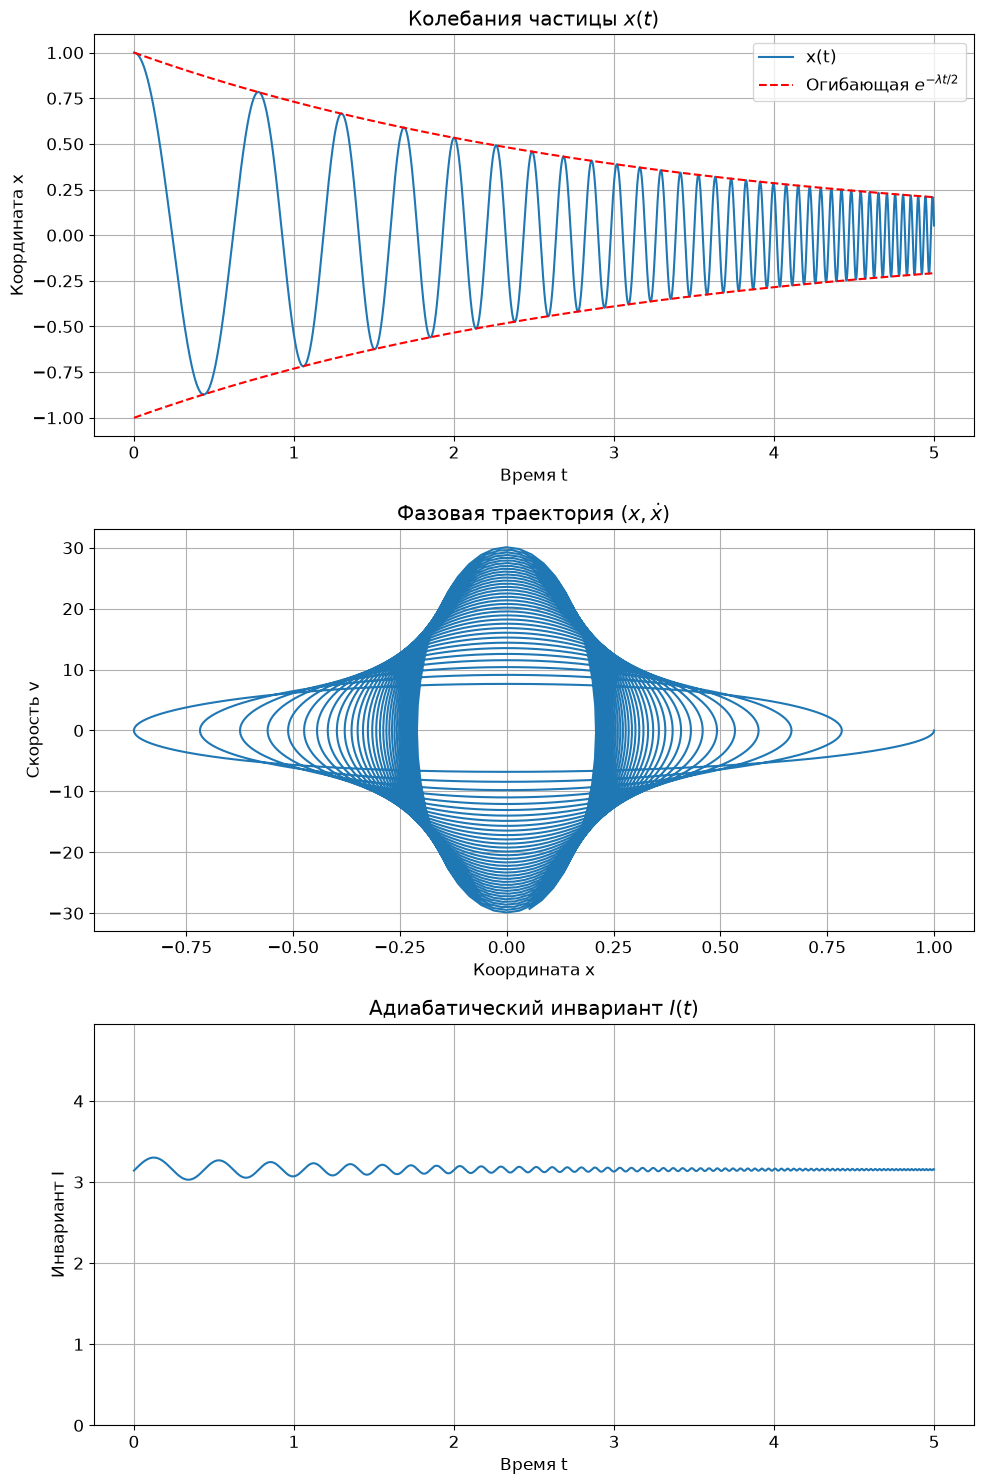

In [4]:
# Визуализация результатов

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# 1. График координаты от времени
axes[0].plot(t, x, label='x(t)')
axes[0].plot(t, np.exp(-lam*t/2)*x0, 'r--', label=r'Огибающая $e^{-\lambda t/2}$') # Теоретическое затухание амплитуды
axes[0].plot(t, -np.exp(-lam*t/2)*x0, 'r--')
axes[0].set_title('Колебания частицы $x(t)$')
axes[0].set_xlabel('Время t')
axes[0].set_ylabel('Координата x')
axes[0].grid(True)
axes[0].legend()

# 2. Фазовая траектория
axes[1].plot(x, v)
axes[1].set_title('Фазовая траектория $(x, \\dot{x})$')
axes[1].set_xlabel('Координата x')
axes[1].set_ylabel('Скорость v')
axes[1].grid(True)
axes[1].set_aspect('auto') # Можно поставить 'equal', но из-за роста скорости график сплющится

# 3. Адиабатический инвариант
axes[2].plot(t, I)
axes[2].set_title('Адиабатический инвариант $I(t)$')
axes[2].set_xlabel('Время t')
axes[2].set_ylabel('Инвариант I')
axes[2].set_ylim(0, max(I)*1.5)
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Итоги

Уравнение осциллятора с экспоненциально растущей частотой сведено к уравнению Бесселя нулевого порядка, и его решение записано через функции $J_0$, $Y_0$.
Построена транспортная матрица, определитель которой равен единице в согласии с теоремой Лиувилля, а её действие на начальные условия совпадает с аналитическим решением.
Адиабатический инвариант $I = E/\omega$ сохраняется с точностью до малых осцилляций при $\lambda \ll \omega$, амплитуда координаты затухает как $e^{-\lambda t/2}$, а фазовая траектория представляет собой спираль, сжимающуюся по координате и растягивающуюся по скорости.